# Assignment 2: End-to-End Machine Learning Pipeline

## Student Name and Student ID
Prabaseelan Vettivelu - 101018683

## Course
MBAI 5310G - AI Programming

## Assignment
Assignment 2: End-to-End Machine Learning Pipeline

## Step 2: Business Problem and Dataset Overview

In this notebook, we use a business account upgrade prediction dataset named `business_account_upgrade_prediction_dataset.xls`.

The main business problem is to predict whether a business account will upgrade its account or not based on the information available in the dataset.

The target variable is `Upgraded_Account`, which has two possible values: `Yes` and `No`. Therefore, this is a supervised binary classification problem.

This type of prediction is useful in business analytics because companies want to identify which business customers are more likely to upgrade. The company can use this information to improve sales follow-up, customer support, training decisions, and marketing strategies.

### Business Question

Can we predict whether a business account will upgrade its account using company information, account activity, product usage, and customer engagement features?

### Dataset Overview

The dataset includes different types of variables, such as company size, industry, annual revenue, monthly transactions, current plan, account age, support tickets, sales contact status, product usage score, monthly fee, training attendance, and upgrade behaviour.

Each row represents one business account. The model will learn patterns from these past account records and use those patterns to classify accounts into upgrade or non-upgrade groups.

### Why This Dataset Is Suitable for Logistic Regression

This dataset is suitable for Logistic Regression because the target variable, `Upgraded_Account`, has two possible outcomes: `Yes` and `No`.

Since the model is predicting one of two categories, Logistic Regression is a suitable baseline model for this assignment. It is simple, commonly used for binary classification, and easy to interpret compared with more advanced models.

### Goal of This Notebook

The goal of this notebook is to build a basic end-to-end machine learning pipeline using a Logistic Regression baseline model.

The notebook will include the following steps:

1. Load and inspect the dataset
2. Understand the business problem
3. Identify the features and target variable
4. Define X and y
5. Clean the data
6. Handle missing values
7. Handle categorical and numerical variables
8. Split the data into training and testing sets
9. Apply preprocessing
10. Train a Logistic Regression baseline model
11. Evaluate the model using accuracy, confusion matrix, precision, recall, and F1-score
12. Interpret the results from a business perspective

After training the model, we will explain what the model is trying to predict, what dataset was used, what features and target were selected, what result was obtained, and one limitation of the model or dataset.

## Step 3: Loading the Dataset

In this step, we load the dataset into Python so that we can inspect, clean, and prepare it for machine learning.

The dataset file used in this notebook is named `business_account_upgrade_prediction_dataset.xls`.

Although the file has an `.xls` extension, the data is comma-separated. Therefore, we use `pd.read_csv()` to load the dataset instead of `pd.read_excel()`.

After loading the dataset, we store it in a DataFrame called `df`. This allows us to inspect the rows, columns, data types, missing values, and other important information before building the machine learning model.

Important: Before running the code, make sure the dataset file is saved in the same folder as this notebook.

In [53]:
# Import pandas library to work with datasets
import pandas as pd

# Import display function to show tables clearly in Jupyter Notebook
from IPython.display import display

# Store the dataset file name in a variable
# Important: Keep the dataset file in the same folder as this notebook
file_path = "business_account_upgrade_prediction_dataset.xls"

# Read the file and load it into a pandas DataFrame
# Although the file extension is .xls, the data is comma-separated, so read_csv is used
df = pd.read_csv(file_path)

# Print a message to confirm that the dataset has been loaded successfully
print("Dataset loaded successfully!")

# Print the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Display the first five rows of the dataset
display(df.head())

Dataset loaded successfully!
Dataset shape: (377, 13)


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


In [2]:
# Print a title for this output
print("Dataset Shape")

# Print a separator line to make the output clear
print("-" * 50)

# Show the number of rows and columns in the dataset
print(df.shape)

Dataset Shape
--------------------------------------------------
(377, 13)


In [3]:
# Print a title for this output
print("First Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the first five rows of the dataset
display(df.head())

First Five Rows of the Dataset
--------------------------------------------------


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


In [4]:
# Print a title for this output
print("Last Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the last five rows of the dataset
display(df.tail())

Last Five Rows of the Dataset
--------------------------------------------------


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
372,314,Large,Education,4054009.0,125,Basic,99,6,No,56.0,3005,No,No
373,261,Small,Finance,5943853.0,190,Business,116,10,Yes,58.0,172,No,No
374,272,Small,Technology,6513840.0,301,Standard,92,9,Yes,69.0,983,Yes,Yes
375,222,Enterprise,Technology,2754584.0,409,Standard,85,5,Yes,95.0,504,No,Yes
376,49,Small,Technology,7512369.0,176,Basic,101,4,Yes,55.0,279,No,No


In [5]:
# Print a title for this output
print("Column Names")

# Print a separator line to make the output clear
print("-" * 50)

# Display all column names as a list
print(df.columns.tolist())

Column Names
--------------------------------------------------
['Account_ID', 'Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended', 'Upgraded_Account']


In [6]:
# Print a title for this output
print("Dataset Information")

# Print a separator line to make the output clear
print("-" * 50)

# Show general information about the dataset
# This includes column names, non-null counts, and data types
df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Account_ID            377 non-null    int64  
 1   Company_Size          370 non-null    str    
 2   Industry              370 non-null    str    
 3   Annual_Revenue        370 non-null    float64
 4   Monthly_Transactions  377 non-null    int64  
 5   Current_Plan          370 non-null    str    
 6   Account_Age_Months    377 non-null    int64  
 7   Support_Tickets       377 non-null    int64  
 8   Sales_Contacted       370 non-null    str    
 9   Product_Usage_Score   370 non-null    float64
 10  Monthly_Fee           377 non-null    int64  
 11  Training_Attended     377 non-null    str    
 12  Upgraded_Account      377 non-null    str    
dtypes: float64(2), int64(5), str(6)
memory usage: 49.1 KB


In [7]:
# Print a title for this output
print("Data Types of Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Display the data type of each column
display(df.dtypes)

Data Types of Each Column
--------------------------------------------------


Account_ID                int64
Company_Size                str
Industry                    str
Annual_Revenue          float64
Monthly_Transactions      int64
Current_Plan                str
Account_Age_Months        int64
Support_Tickets           int64
Sales_Contacted             str
Product_Usage_Score     float64
Monthly_Fee               int64
Training_Attended           str
Upgraded_Account            str
dtype: object

In [8]:
# Print a title for this output
print("Missing Values in Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
display(missing_values)

Missing Values in Each Column
--------------------------------------------------


Account_ID              0
Company_Size            7
Industry                7
Annual_Revenue          7
Monthly_Transactions    0
Current_Plan            7
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         7
Product_Usage_Score     7
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64

In [9]:
# Print a title for this output
print("Number of Duplicate Rows")

# Print a separator line to make the output clear
print("-" * 50)

# Count the number of duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

# Display the number of duplicate rows
print(duplicate_rows)

Number of Duplicate Rows
--------------------------------------------------
7


In [10]:
# Print a title for this output
print("Summary Statistics for Numerical Columns")

# Print a separator line to make the output clear
print("-" * 50)

# Display summary statistics for numerical columns
display(df.describe())

Summary Statistics for Numerical Columns
--------------------------------------------------


,Account_ID,Annual_Revenue,Monthly_Transactions,Account_Age_Months,Support_Tickets,Product_Usage_Score,Monthly_Fee
count,377.000000,3.700000e+02,377.000000,377.000000,377.000000,370.000000,377.000000
mean,186.265252,4.060962e+06,248.880637,60.962865,6.933687,51.102703,2408.000000
std,106.726653,2.315737e+06,140.723205,35.513763,4.266190,28.988835,1430.944912
min,1.000000,8.265600e+04,0.000000,1.000000,0.000000,0.000000,83.000000
25%,94.000000,1.902595e+06,130.000000,30.000000,4.000000,27.000000,1231.000000
50%,187.000000,4.182715e+06,248.000000,62.000000,7.000000,51.500000,2414.000000
75%,278.000000,6.017136e+06,363.000000,93.000000,10.000000,76.000000,3623.000000
max,370.000000,7.987036e+06,499.000000,119.000000,14.000000,100.000000,4999.000000


In [11]:
# Check the distribution of the target variable
print("Target variable distribution:")
print(df["Upgraded_Account"].value_counts())

Target variable distribution:
Upgraded_Account
No     293
Yes     84
Name: count, dtype: int64


## Step 5: Understanding Features and Target Variable

In this step, we identify the input features and the target variable of the dataset.

The target variable is the column that we want the machine learning model to predict.

In this dataset, the target variable is `Upgraded_Account`. It shows whether a business account upgraded its account or not.

The possible values of the target variable are:

- `Yes`: the business account upgraded
- `No`: the business account did not upgrade

Because the target variable has two possible categories, this is a supervised binary classification problem.

The features are the input columns that help the model make the prediction. These features include business account information, account activity, product usage, sales contact status, and training-related information.

Examples of features in this dataset include:

- Company size
- Industry
- Annual revenue
- Monthly transactions
- Current plan
- Account age in months
- Support tickets
- Sales contacted
- Product usage score
- Monthly fee
- Training attended

The column `Account_ID` is not used as a feature because it is only an identification number. It does not provide meaningful information for predicting whether an account will upgrade.

Therefore:

- `X` = feature variables used to make predictions
- `y` = target variable, `Upgraded_Account`

In [12]:
# Store the target column name in a variable
target_column = "Upgraded_Account"

# Print the target variable name
print("Target variable:")
print(target_column)

Target variable:
Upgraded_Account


In [13]:
# Print the unique values in the target column
print("Target variable values:")
print("-" * 50)
print(df[target_column].unique())

Target variable values:
--------------------------------------------------
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [14]:
# Count how many accounts are in each target class
target_counts = df[target_column].value_counts()

# Display the target class distribution
print("Target class distribution:")
print("-" * 50)
display(target_counts)

Target class distribution:
--------------------------------------------------


Upgraded_Account
No     293
Yes     84
Name: count, dtype: int64

In [15]:
# Create a list of possible feature columns by removing the target column
feature_columns = df.drop(columns=[target_column]).columns.tolist()

# Print the possible feature columns
print("Possible feature columns:")
print("-" * 50)
print(feature_columns)

Possible feature columns:
--------------------------------------------------
['Account_ID', 'Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended']


In [16]:
# Select numerical columns from the dataset
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical columns from the dataset
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

# Remove the target column from categorical columns because it is not an input feature
if target_column in categorical_columns:
    categorical_columns.remove(target_column)

# Print numerical columns
print("Numerical feature columns:")
print(numerical_columns)

print("-" * 50)

# Print categorical columns
print("Categorical feature columns:")
print(categorical_columns)

Numerical feature columns:
['Account_ID', 'Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']
--------------------------------------------------
Categorical feature columns:
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


C:\Users\praba\AppData\Local\Temp\ipykernel_29988\2900592511.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


### Short Interpretation

The target variable is `Upgraded_Account`. This means the model will try to predict whether a business account upgraded or not.

The remaining columns are possible input features. These features describe company characteristics, account activity, product usage, sales contact status, and training-related information.

The column `Account_ID` is only an identification number. Therefore, it should not be used as a final feature for model training because it does not provide meaningful predictive information.

At this stage, we only identify the target variable and possible feature columns. After data cleaning, the final `X` and `y` variables will be created for model training.

## Step 6: Data Cleaning

Before training a machine learning model, we need to clean the dataset.

In this step, we create a copy of the original dataset and remove duplicate rows.

Duplicate rows can affect the model because repeated records may give extra weight to the same information.

At this stage, we do not fill missing values yet. Missing values will be handled in the next step before defining the final feature and target variables.

In [17]:
# Create a copy of the original dataset
df_clean = df.copy()

# Print a message to confirm that the copy was created
print("A copy of the dataset has been created.")

# Show the shape of the original dataset
print("Original dataset shape:", df.shape)

# Show the shape of the copied dataset
print("Copied dataset shape:", df_clean.shape)

A copy of the dataset has been created.
Original dataset shape: (377, 13)
Copied dataset shape: (377, 13)


In [18]:
# Count the number of duplicate rows before cleaning
duplicates_before = df_clean.duplicated().sum()

# Print the number of duplicate rows before cleaning
print("Number of duplicate rows before cleaning:", duplicates_before)

Number of duplicate rows before cleaning: 7


In [19]:
# Remove duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()

# Print a message to confirm that duplicate rows were removed
print("Duplicate rows have been removed.")

Duplicate rows have been removed.


In [20]:
# Show the shape of the dataset after removing duplicate rows
print("Dataset shape after removing duplicates:", df_clean.shape)

# Count the number of duplicate rows after cleaning
duplicates_after = df_clean.duplicated().sum()

# Print the number of duplicate rows after cleaning
print("Number of duplicate rows after cleaning:", duplicates_after)

Dataset shape after removing duplicates: (370, 13)
Number of duplicate rows after cleaning: 0


In [21]:
# Display the first five rows of the cleaned dataset
display(df_clean.head())

,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


## Step 7: Handling Missing Values

In this step, we handle missing values in the cleaned dataset.

Missing values can cause errors during model training because most machine learning algorithms cannot work with empty cells.

For numerical feature columns, missing values are filled using the median value of each column.

For categorical feature columns, missing values are filled using the most frequent value, also called the mode.

The target variable, `Upgraded_Account`, should not be filled using median or mode. If the target variable has missing values, those rows should be removed because the model needs a known answer to learn from the data.

This step helps prepare a more complete dataset for machine learning.

In [22]:
# Print a title for this output
print("Missing Values Before Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column before handling them
missing_values_before = df_clean.isnull().sum()

# Display missing values before handling
display(missing_values_before)

Missing Values Before Handling
--------------------------------------------------


Account_ID              0
Company_Size            7
Industry                7
Annual_Revenue          7
Monthly_Transactions    0
Current_Plan            7
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         7
Product_Usage_Score     7
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64

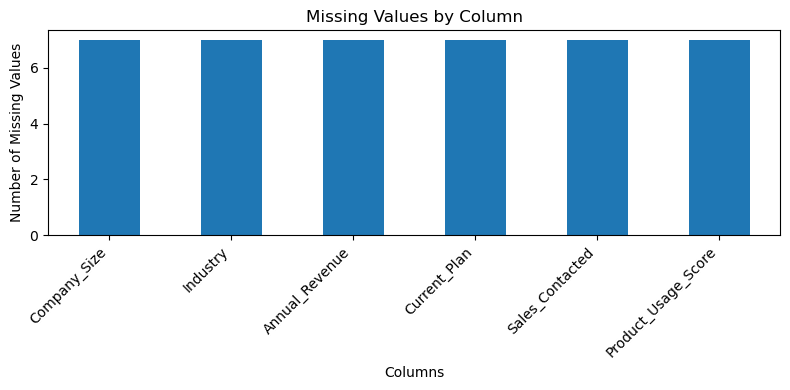

In [23]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Select only columns that have missing values
missing_columns = missing_values_before[missing_values_before > 0]

# Check whether there are missing values before creating the chart
if len(missing_columns) > 0:
    
    # Create a figure for the missing values chart
    plt.figure(figsize=(8, 4))
    
    # Create a bar chart for columns with missing values
    missing_columns.plot(kind="bar")
    
    # Add a title to the chart
    plt.title("Missing Values by Column")
    
    # Add a label to the x-axis
    plt.xlabel("Columns")
    
    # Add a label to the y-axis
    plt.ylabel("Number of Missing Values")
    
    # Rotate x-axis labels to make them easier to read
    plt.xticks(rotation=45, ha="right")
    
    # Adjust the layout so labels do not overlap
    plt.tight_layout()
    
    # Display the chart
    plt.show()

else:
    print("There are no missing values to display in a chart.")

In [24]:
# Check whether the target variable has missing values
missing_target_values = df_clean[target_column].isnull().sum()

print("Missing values in target variable:", missing_target_values)

Missing values in target variable: 0


In [25]:
# Remove rows where the target variable is missing, if any
# The model needs a known target value to learn from the data
df_clean = df_clean.dropna(subset=[target_column])

# Print the dataset shape after checking the target variable
print("Dataset shape after checking target missing values:", df_clean.shape)

Dataset shape after checking target missing values: (370, 13)


In [26]:
# Define columns that should not be filled as normal features
columns_to_exclude = ["Account_ID", target_column]

# Create a feature-only dataset for identifying numerical and categorical feature columns
feature_data_for_missing = df_clean.drop(columns=columns_to_exclude, errors="ignore")

# Select numerical feature columns from the cleaned dataset
numerical_columns = feature_data_for_missing.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical feature columns from the cleaned dataset
categorical_columns = feature_data_for_missing.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# Print numerical columns
print("Numerical feature columns:")
print(numerical_columns)

print("-" * 50)

# Print categorical columns
print("Categorical feature columns:")
print(categorical_columns)

Numerical feature columns:
['Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']
--------------------------------------------------
Categorical feature columns:
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


In [27]:
# Loop through each numerical feature column
for column in numerical_columns:
    
    # Calculate the median value of the current numerical column
    median_value = df_clean[column].median()
    
    # Fill missing values in the current column with the median value
    df_clean[column] = df_clean[column].fillna(median_value)

# Print a message after handling numerical missing values
print("Missing values in numerical feature columns have been filled with the median.")

Missing values in numerical feature columns have been filled with the median.


In [28]:
# Loop through each categorical feature column
for column in categorical_columns:
    
    # Calculate the most frequent value of the current categorical column
    mode_value = df_clean[column].mode()[0]
    
    # Fill missing values in the current column with the most frequent value
    df_clean[column] = df_clean[column].fillna(mode_value)

# Print a message after handling categorical missing values
print("Missing values in categorical feature columns have been filled with the mode.")

Missing values in categorical feature columns have been filled with the mode.


In [29]:
# Print a title for this output
print("Missing Values After Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values after handling them
missing_values_after = df_clean.isnull().sum()

# Display missing values after handling
display(missing_values_after)

Missing Values After Handling
--------------------------------------------------


Account_ID              0
Company_Size            0
Industry                0
Annual_Revenue          0
Monthly_Transactions    0
Current_Plan            0
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         0
Product_Usage_Score     0
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64

In [30]:
# Print the shape of the cleaned dataset after handling missing values
print("Dataset shape after handling missing values:", df_clean.shape)

# Display the first five rows of the cleaned dataset
display(df_clean.head())

Dataset shape after handling missing values: (370, 13)


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


### Short Interpretation

The missing values have now been handled.

Numerical missing values were replaced with the median, and categorical missing values were replaced with the most frequent value.

The target variable was checked separately because it should not be filled like a normal feature column.

Now the dataset is more complete and ready for the next step: handling categorical and numerical variables.

## Step 8: Handling Categorical and Numerical Variables

In this step, we identify numerical and categorical variables in the cleaned dataset.

Numerical variables contain numbers, such as annual revenue, monthly transactions, account age, support tickets, product usage score, and monthly fee.

Categorical variables contain groups or labels, such as company size, industry, current plan, sales contacted, and training attended.

This step is important because machine learning models need numerical input.

Later, we will convert categorical variables into numerical format during preprocessing using one-hot encoding.

The columns `Account_ID` and `Upgraded_Account` are excluded from the feature list. `Account_ID` is only an identifier, and `Upgraded_Account` is the target variable.

In [31]:
# Define the target column name
target_column = "Upgraded_Account"

# Print the target column name
print("Target column:")
print(target_column)

Target column:
Upgraded_Account


In [32]:
# Create a feature-only dataset by removing Account_ID and the target column
feature_data = df_clean.drop(columns=["Account_ID", target_column])

# Select numerical feature columns from the feature-only dataset
numerical_features = feature_data.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Print a title for numerical features
print("Numerical feature columns:")
print("-" * 50)

# Display numerical feature columns
print(numerical_features)

Numerical feature columns:
--------------------------------------------------
['Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']


In [33]:
# Select categorical feature columns from the feature-only dataset
categorical_features = feature_data.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# Print a title for categorical features
print("Categorical feature columns:")
print("-" * 50)

# Display categorical feature columns
print(categorical_features)

Categorical feature columns:
--------------------------------------------------
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


In [34]:
# Count the number of numerical features
num_count = len(numerical_features)

# Count the number of categorical features
cat_count = len(categorical_features)

# Print the number of numerical features
print("Number of numerical features:", num_count)

# Print the number of categorical features
print("Number of categorical features:", cat_count)

Number of numerical features: 6
Number of categorical features: 5


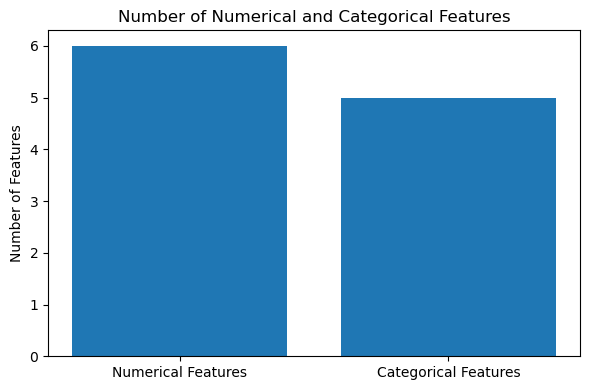

In [35]:
# Create labels for the chart
feature_type_labels = ["Numerical Features", "Categorical Features"]

# Create values for the chart
feature_type_counts = [num_count, cat_count]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart
plt.bar(feature_type_labels, feature_type_counts)

# Add a chart title
plt.title("Number of Numerical and Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Features")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [36]:
# Print a title for unique values
print("Unique values in categorical features")
print("-" * 50)

# Loop through each categorical feature
for column in categorical_features:
    
    # Print the column name
    print("Column:", column)
    
    # Print the unique values in the column
    print(df_clean[column].unique())
    
    # Print a separator line
    print("-" * 50)

Unique values in categorical features
--------------------------------------------------
Column: Company_Size
<ArrowStringArray>
['Small', 'Enterprise', 'Large', 'Medium']
Length: 4, dtype: str
--------------------------------------------------
Column: Industry
<ArrowStringArray>
['Healthcare', 'Manufacturing', 'Education', 'Finance', 'Technology',
 'Retail']
Length: 6, dtype: str
--------------------------------------------------
Column: Current_Plan
<ArrowStringArray>
['Business', 'Basic', 'Premium', 'Standard']
Length: 4, dtype: str
--------------------------------------------------
Column: Sales_Contacted
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
Column: Training_Attended
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------


In [37]:
# Count unique values for each categorical feature
categorical_unique_counts = df_clean[categorical_features].nunique()

# Print a title
print("Number of unique values in each categorical feature:")
print("-" * 50)

# Display the number of unique values
display(categorical_unique_counts)

Number of unique values in each categorical feature:
--------------------------------------------------


Company_Size         4
Industry             6
Current_Plan         4
Sales_Contacted      2
Training_Attended    2
dtype: int64

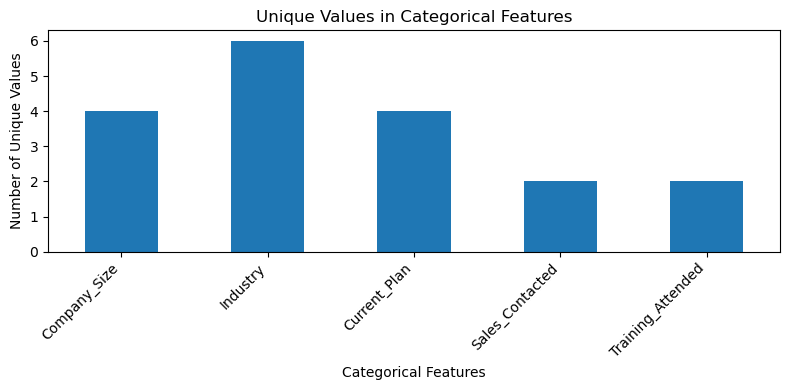

In [38]:
# Create a figure for the categorical unique values chart
plt.figure(figsize=(8, 4))

# Create a bar chart for unique values in categorical columns
categorical_unique_counts.plot(kind="bar")

# Add a chart title
plt.title("Unique Values in Categorical Features")

# Add a label to the x-axis
plt.xlabel("Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Unique Values")

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

### Short Interpretation

The dataset contains both numerical and categorical features.

Numerical features can be used by the model after scaling, while categorical features must be converted into numerical format before training.

In this project, categorical features will be converted using one-hot encoding during preprocessing.

The next step is to define `X` and `y`, where `X` contains the feature variables and `y` contains the target variable, `Upgraded_Account`.

## Step 9: Define X and y

In this step, we separate the cleaned dataset into feature variables and the target variable.

The target variable is `Upgraded_Account`. This is the variable that the model is trying to predict.

The feature variables are the input columns that the model will use to make predictions.

The `Account_ID` column is removed because it is only an identification number. It does not provide meaningful information for predicting whether an account will upgrade.

Therefore:

- `X` = feature variables used to make predictions
- `y` = target variable, `Upgraded_Account`

After this step, `X` will contain the input columns, and `y` will contain the answer column that the model needs to learn from.

In [39]:
# Define the target variable
target = "Upgraded_Account"

# Define X by removing the target column and Account_ID from the cleaned dataset
X = df_clean.drop(columns=[target, "Account_ID"])

# Define y as the target variable from the cleaned dataset
y = df_clean[target]

# Display the shape of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Display selected feature columns
print("\nFeature columns:")
print(X.columns.tolist())

# Display target variable name
print("\nTarget variable:")
print(target)

Shape of X: (370, 11)
Shape of y: (370,)

Feature columns:
['Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended']

Target variable:
Upgraded_Account


In [40]:
# Show the first five rows of X
display(X.head())

,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended
0,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes
1,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes
2,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No
3,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No
4,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes


In [41]:
# Show the first five values of y
display(y.head())

0     No
1     No
2     No
3    Yes
4     No
Name: Upgraded_Account, dtype: str

## Step 10: Train/Test Split

The dataset is split into training and testing sets.

The training set is used to train the model. The testing set is kept separate and used to evaluate the model on unseen data.

This helps us check whether the model can generalize to new business accounts.

I used:

- 80% of the data for training
- 20% of the data for testing
- `random_state=42` to make the split reproducible
- `stratify=y` to keep the Yes/No target balance similar in both training and testing sets

In [42]:
# Import train_test_split to split the dataset
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shape of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (296, 11)
X_test shape: (74, 11)
y_train shape: (296,)
y_test shape: (74,)


In [43]:
# Check the target distribution in training data
print("Training target distribution:")
print(y_train.value_counts())

print("-" * 50)

# Check the target distribution in testing data
print("Testing target distribution:")
print(y_test.value_counts())

Training target distribution:
Upgraded_Account
No     230
Yes     66
Name: count, dtype: int64
--------------------------------------------------
Testing target distribution:
Upgraded_Account
No     58
Yes    16
Name: count, dtype: int64


## Step 11: Preprocessing

Preprocessing prepares the data for the machine learning model.

For numerical variables:

- Values are scaled using StandardScaler

For categorical variables:

- Categories are converted into numerical format using OneHotEncoder

The preprocessing is included inside a pipeline. This makes the workflow organized and helps apply the same preprocessing steps to both training and testing data.

Since missing values were already handled in the previous step, this preprocessing step focuses mainly on scaling numerical features and encoding categorical features.

In [44]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create preprocessing steps for numerical columns
numerical_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Create preprocessing steps for categorical columns
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## Step 12: Logistic Regression Baseline Model

For this assignment, I used Logistic Regression as the baseline classification model.

Logistic Regression is suitable here because the target variable has two categories:

- `Yes`
- `No`

The model will learn patterns from the training data and predict whether a business account is likely to upgrade.

In [45]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the full machine learning pipeline
# The pipeline first preprocesses the data and then trains the Logistic Regression model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Step 13: Model Prediction

After training the model, I use the testing data to make predictions.

The testing data was not used during training, so it helps evaluate how the model performs on unseen data.

In [46]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Display the first ten predictions
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No']


## Step 14: Model Evaluation

The model is evaluated using:

1. Accuracy
2. Confusion Matrix
3. Classification Report

Accuracy shows the overall percentage of correct predictions.

The confusion matrix shows correct and incorrect predictions for both classes.

The classification report shows precision, recall, and F1-score for each class.

In [47]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.7567567567567568
Accuracy percentage: 75.68 %


In [48]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["No", "Yes"])

# Convert confusion matrix to a DataFrame for clearer display
cm_df = pd.DataFrame(
    cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

# Display confusion matrix
print("Confusion Matrix:")
display(cm_df)

Confusion Matrix:


,Predicted No,Predicted Yes
Actual No,51,7
Actual Yes,11,5


In [49]:
# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.88      0.85        58
         Yes       0.42      0.31      0.36        16

    accuracy                           0.76        74
   macro avg       0.62      0.60      0.60        74
weighted avg       0.73      0.76      0.74        74



## Step 15: Result Interpretation

The Logistic Regression model was used as a baseline model to predict whether a business account would upgrade or not.

The accuracy score shows the overall percentage of correct predictions made by the model on the test data.

The confusion matrix helps us understand how many accounts were correctly or incorrectly classified as upgrade or non-upgrade accounts.

The classification report provides precision, recall, and F1-score for each class. These metrics are useful because accuracy alone may not fully explain model performance, especially if the dataset has more `No` values than `Yes` values.

From a business perspective, the model can help identify accounts that may be more likely to upgrade. However, the results should be used carefully because this is only a baseline model.

In [50]:
# Print a simple automatic result summary
print("Model Result Summary")
print("-" * 50)
print("The model is trying to predict whether a business account will upgrade or not.")
print("The target variable is Upgraded_Account.")
print("The baseline model used is Logistic Regression.")
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Model Result Summary
--------------------------------------------------
The model is trying to predict whether a business account will upgrade or not.
The target variable is Upgraded_Account.
The baseline model used is Logistic Regression.
Accuracy percentage: 75.68 %


## Step 16: Final Explanation and Limitation

### What is the model trying to predict?

The model is trying to predict whether a business account will upgrade its account or not.

### What dataset was used?

The dataset used in this assignment is `business_account_upgrade_prediction_dataset.xls`.

This dataset contains business account information such as company size, industry, annual revenue, monthly transactions, current plan, account age, support tickets, sales contact status, product usage score, monthly fee, training attendance, and whether the account upgraded.

### What features and target were selected?

The target variable selected for prediction is `Upgraded_Account`.

The feature variables selected are:

- Company_Size
- Industry
- Annual_Revenue
- Monthly_Transactions
- Current_Plan
- Account_Age_Months
- Support_Tickets
- Sales_Contacted
- Product_Usage_Score
- Monthly_Fee
- Training_Attended

The column `Account_ID` was removed because it is only an identifier and does not provide useful predictive information.

### What result was obtained?

The baseline Logistic Regression model was trained and tested using the dataset.

The model achieved an accuracy of approximately 76%, specifically 75.68% on the test data. This means the model correctly predicted about 76% of the test accounts.

The confusion matrix and classification report show that the model performs better in predicting accounts that did not upgrade than accounts that upgraded.

### One limitation of the model or dataset

One limitation is that the dataset is imbalanced. There are more accounts that did not upgrade than accounts that upgraded. Because of this, the model may be better at predicting the majority class, which is `No`, and weaker at identifying accounts that actually upgraded.

Another limitation is that Logistic Regression is only a simple baseline model. More advanced models or additional business variables may improve performance.

## Step 17: Responsible AI Reflection

This model should be used as a decision-support tool, not as the only basis for business decisions.

The model predicts whether a business account is likely to upgrade, but it may still make incorrect predictions. For example, some accounts that are predicted as unlikely to upgrade may actually upgrade later, and some accounts predicted as likely to upgrade may not upgrade.

The company should not use the model to unfairly ignore or exclude customers. Human judgment is still important, especially when making sales, support, pricing, or customer relationship decisions.

One responsible AI concern is class imbalance. Since there are more accounts that did not upgrade than accounts that upgraded, the model may perform better for the majority class and may be weaker at identifying upgrade customers.

Another concern is data quality. If the dataset contains missing values, outdated information, or limited business variables, the model’s predictions may not fully reflect real customer behaviour.

Therefore, before using this model in a real business setting, the company should test it further, monitor its performance, check for bias, and make sure the predictions are used fairly and responsibly.

## Step 18: GitHub Submission Note

For submission, I will upload the completed Jupyter Notebook and dataset to my GitHub repository.

The repository will include:

- The completed notebook
- The dataset file
- A README file explaining the project
- The GitHub repository link submitted on Canvas

The notebook should run from top to bottom without errors.